# 单因子分析 - 动量因子 (mom_20d)

这个 notebook 不是只看结果，而是按一套标准的单因子检测流程，逐步回答 3 个问题：

1. 这个因子有没有被正确构造和清洗。
2. 这个因子对未来收益有没有横截面预测力。
3. 这个因子即使有效，稳定性和可落地性够不够。

## 流程对照表

- Step 0: 准备样本、因子和未来收益标签。
- Step 1: 看因子分布是否健康，确认数据本身能不能用于研究。
- Step 2: 看 IC 是否持续为正，确认因子排序和未来收益排序是否同向。
- Step 3: 看分层收益是否单调，确认高分组是否整体好于低分组。
- Step 4: 看 Q5-Q1 多空是否成立，把高低分差异压缩成一个收益序列。
- Step 5: 看稳定性和换手，判断这个因子是不是经得起时间和调仓。
- Step 6: 汇总评分卡，把多张图和多个指标合在一起下结论。

## 新手读图方式

每张图都按 4 个问题看：

1. 📌 这张图回答什么问题。
2. 👀 横轴、纵轴、颜色分别代表什么。
3. ✅ 理想情况下应该长什么样。
4. ⚠️ 当前图里有哪些结论和风险。

## 关键代码在哪里

- 数据读取与基础清洗：`src/factor_utils.py` 里的 `load_daily_panel`。
- 因子构造：`compute_momentum`。
- 预处理流程：`winsorize_mad`、`cross_sectional_zscore`、`neutralize_by_size`、`build_factor`。
- 核心检验：`compute_rank_ic`、`compute_quantile_returns`、`long_short_spread`、`factor_autocorr`。

当前示例用的是 mock 数据，所以重点是在把检测流程走通。后面接真实 A 股数据时，这套解释仍然成立。


In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# 图表样式：标题尽量保持英文，避免 notebook 导出时出现字体回退问题。
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.titlesize": 13,
    "legend.fontsize": 9,
    "axes.unicode_minus": False,
    "axes.edgecolor": "#D0D5DD",
    "grid.color": "#D9DEE7",
    "grid.linewidth": 0.8,
})

COLORS = {
    "blue": "#4E79A7",
    "teal": "#2A9D8F",
    "green": "#59A14F",
    "orange": "#F28E2B",
    "red": "#E15759",
    "purple": "#B07AA1",
    "gray": "#6B7280",
}
QUANTILE_COLORS = [COLORS["blue"], COLORS["teal"], COLORS["gray"], COLORS["orange"], COLORS["green"]]
HORIZON_COLORS = [COLORS["blue"], COLORS["orange"], COLORS["green"]]
C = sns.color_palette([COLORS[k] for k in ["blue", "teal", "green", "orange", "red", "purple"]])

# 参数配置
FACTOR_WINDOW = 20
FORWARD_HORIZONS = [1, 5, 20]
N_QUANTILES = 5
RNG = np.random.default_rng(42)
N_DATES, N_STOCKS = 200, 100


In [2]:
# ── 生成示例数据 ──
def make_mock_data(n_dates=N_DATES, n_stocks=N_STOCKS):
    dates = pd.bdate_range("2022-01-03", periods=n_dates)
    industries = np.array(["电子", "医药", "银行", "机械", "消费"])
    
    codes = []
    for i in range(n_stocks):
        if i < n_stocks // 2:
            codes.append(f"{600000 + i:06d}.SH")
        else:
            codes.append(f"{300000 + i - n_stocks // 2:06d}.SZ")
    
    ind_map = RNG.choice(industries, n_stocks)
    size_base = RNG.lognormal(mean=3.2, sigma=0.8, size=n_stocks)
    
    frames = []
    for i, code in enumerate(codes):
        eps = RNG.normal(0, 0.016, n_dates)
        ret = np.zeros(n_dates)
        ret[0] = eps[0]
        for t in range(1, n_dates):
            ret[t] = 0.05 * ret[t-1] + eps[t]
        drift = RNG.normal(0, 0.0004)
        price = 10.0 * np.exp(np.cumsum(ret + drift))
        mv = price * size_base[i] * 1e8
        
        df = pd.DataFrame({
            "trade_date": dates,
            "ts_code": code,
            "close": price,
            "total_mv": mv,
            "is_suspended": False,
            "sw_l1_name": ind_map[i],
        })
        frames.append(df)
    
    panel = pd.concat(frames, ignore_index=True)
    n = len(panel)
    panel.loc[RNG.choice(n, n // 120, replace=False), "is_suspended"] = True
    panel.loc[RNG.choice(n, n // 100, replace=False), "close"] = np.nan
    panel.loc[RNG.choice(n, n // 80, replace=False), "total_mv"] = np.nan
    return panel.sort_values(["trade_date", "ts_code"]).reset_index(drop=True)


df = make_mock_data()
print(f"{len(df):,} rows x {df.ts_code.nunique()} stocks x {df.trade_date.nunique()} dates")


20,000 rows x 100 stocks x 200 dates


---
## Step 0. 因子构造与标签定义

这一步对应单因子研究里最前面的“信号定义 + 标签定义 + 样本口径”范式。后面所有 IC、分层和多空，都是建立在这里的定义之上。

当前 notebook 用的是 **20 日动量因子**，具体口径是：

- 因子值：`mom_20d = close_t / close_{t-20} - 1`。
- 收益标签：`fwd_1d`、`fwd_5d`、`fwd_20d`。
- 主检验标签：当前后面主要看 `fwd_5d`。
- 样本过滤：停牌、收盘价缺失、市值缺失或非正值的样本不进入有效股票池。

## 这里对应的标准流程细节

- `compute_momentum`: 对应“原始因子定义”。这里是最基础的 price momentum 版本。
- `compute_forward_returns`: 对应“未来收益标签构造”。这里刻意用未来区间收益，而不是当期收益。
- `winsorize_mad`: 对应“截面去极值”。范式是先清异常值，再做标准化。
- `cross_sectional_zscore`: 对应“截面标准化”。让不同日期的因子值可比较。
- `neutralize_by_size`: 对应“风险暴露剥离”。当前只做了市值中性化。
- `assign_quantiles`: 对应“横截面排序分组”。后面的分层收益和多空都用它。

## 这段代码想表达的研究规范

1. 先定义信号，再定义未来收益标签，避免把解释变量和被解释变量混在一起。
2. 先过滤无效样本，再做截面预处理，避免脏数据把分组关系带歪。
3. 先得到 `factor_raw -> factor_zscore -> factor_neutral`，再决定到底用哪一版因子进入检验。
4. 当前选择 `factor_neutral` 作为主因子列，代表我们默认“因子效果尽量不让市值暴露替代”。


In [3]:
# -- 因子构造流程：把每个函数明确映射到单因子研究步骤 --
# 1) 定义原始信号：这里使用 20 日价格动量。
def compute_momentum(df, window=20):
    df = df.sort_values(["ts_code", "trade_date"]).copy()
    df["mom_20d"] = df.groupby("ts_code")["close"].transform(
        lambda s: s / s.shift(window) - 1)
    return df

# 2) 定义未来收益标签。
#    这里采用 T+1 到 T+h+1 的区间收益：close[T+h+1] / close[T+1] - 1。
#    这样可以避免把 T 日收盘价同时用于因子计算和收益起点，减少同日信息污染。
def compute_forward_returns(df, horizons=(1, 5, 20)):
    df = df.sort_values(["ts_code", "trade_date"]).copy()
    for h in horizons:
        df[f"fwd_{h}d"] = df.groupby("ts_code")["close"].transform(
            lambda s: s.shift(-(h + 1)) / s.shift(-1) - 1)
    return df

# 3) 在每个截面内做 MAD 缩尾，先压掉极端值，再进入排序和分组。
def winsorize_mad(series, n=3.0):
    med, mad = series.median(), (series - series.median()).abs().median()
    if pd.isna(mad) or mad == 0:
        return series
    scale = n * 1.4826 * mad
    return series.clip(med - scale, med + scale)

# 4) 在每个交易日内部做标准化，让不同日期的因子值处在可比尺度上。
def cross_sectional_zscore(series):
    std = series.std(ddof=0)
    return (series - series.mean()) / std if std > 0 else pd.Series(0.0, index=series.index)

# 5) 做市值中性化：用因子对对数总市值回归，并保留残差作为中性化后的因子。
def neutralize_by_size(df, factor_col):
    df = df.copy()
    df["factor_neutral"] = np.nan
    for _, g in df.groupby("trade_date"):
        mask = g["total_mv"].notna() & g["total_mv"].gt(0) & g[factor_col].notna()
        if mask.sum() < 5:
            continue
        x = np.log(g.loc[mask, "total_mv"].values)
        y = g.loc[mask, factor_col].values
        beta = np.linalg.lstsq(np.column_stack([np.ones(len(x)), x]), y, rcond=None)[0]
        resid = y - np.column_stack([np.ones(len(x)), x]) @ beta
        resid = (resid - resid.mean()) / resid.std(ddof=0)
        df.loc[g.index[mask], "factor_neutral"] = resid
    return df

# 6) 把处理后的因子转换成截面分组，得到相对强弱分桶。
def assign_quantiles(df, factor_col, n_quantiles=5):
    df = df.copy()
    df["quantile"] = pd.NA
    for _, g in df.groupby("trade_date"):
        mask = g[factor_col].notna()
        if mask.sum() < n_quantiles:
            continue
        df.loc[g.index[mask], "quantile"] = pd.qcut(
            g.loc[mask, factor_col].rank(method="first"),
            q=n_quantiles, labels=range(1, n_quantiles + 1))
    return df.astype({"quantile": "Int64"})


# 按标准单因子研究流程依次执行：先造因子，再造标签，再做截面预处理。
df = compute_momentum(df, FACTOR_WINDOW)
df = compute_forward_returns(df, FORWARD_HORIZONS)

# 先定义有效股票池，再只在这个数据范围内做后续截面处理，避免脏数据把分组关系带歪。
valid = (df["close"].notna() & ~df["is_suspended"]
         & df["total_mv"].notna() & df["total_mv"].gt(0)
         & df["mom_20d"].notna() & df["fwd_20d"].notna())
df["universe"] = valid

# 因子加工顺序遵循常见研究约定：
# 原始因子 -> 缩尾后的因子 -> 标准化因子 -> 市值中性化因子。
df["factor_raw"] = df.groupby("trade_date")["mom_20d"].transform(winsorize_mad)
df["factor_zscore"] = df.groupby("trade_date")["factor_raw"].transform(cross_sectional_zscore)
df = neutralize_by_size(df, "factor_zscore")

# 后续分组默认使用中性化后的因子，因为这里希望检验的是剔除市值暴露后的信号强度。
df = assign_quantiles(df, "factor_neutral", N_QUANTILES)

# 本 notebook 的主测试口径：使用 factor_neutral 作为主因子列，使用 fwd_5d 作为主收益列。
FACTOR_COL = "factor_neutral"
FWD_COL = "fwd_5d"

print(f"有效样本：{df.universe.sum():,} / {len(df):,} 行")
display(df[df.universe][["trade_date", "ts_code", "mom_20d", "factor_raw",
                           "factor_zscore", "factor_neutral", "quantile"]].head(8))



Valid sample: 14,983 / 20,000 rows


,trade_date,ts_code,mom_20d,factor_raw,factor_zscore,factor_neutral,quantile
2000,2022-01-31,300000.SZ,-0.0977,-0.0977,-1.3078,-1.3633,1
2100,2022-02-01,300000.SZ,-0.0820,-0.0820,-1.1726,-1.1976,1
2200,2022-02-02,300000.SZ,-0.0342,-0.0342,-0.5462,-0.6358,2
2300,2022-02-03,300000.SZ,-0.0476,-0.0476,-0.7320,-0.8238,1
2400,2022-02-04,300000.SZ,-0.0542,-0.0542,-0.7751,-0.8649,1
2500,2022-02-07,300000.SZ,-0.0181,-0.0181,-0.2980,-0.3466,2
2600,2022-02-08,300000.SZ,-0.0486,-0.0486,-0.7027,-0.7761,2
2900,2022-02-11,300000.SZ,-0.0699,-0.0699,-0.8928,-0.9557,1


---
## Step 1. 因子分布

这一步先不判断因子赚钱不赚钱，而是先判断“这个因子值本身有没有研究价值”。如果分布已经很怪，后面的 IC、分层收益、多空收益都可能被脏数据带偏。

## 这张图回答什么

- 📌 它回答：因子值是不是集中、是否有极端值、标准化和市值中性化有没有正常生效。
- 👀 横轴是因子值，越靠右代表因子越高；纵轴是股票样本数量，柱子越高代表落在这个区间的股票越多。
- 🔴 红色虚线是均值，深色竖线是中位数。两条线越接近，说明分布越对称。

## 三个子图怎么读

- `Raw`：原始 20 日动量。它保留了真实收益率尺度，例如 0.05 大致代表过去 20 日涨了 5%。
- `Z-score`：截面标准化后的因子。均值应该接近 0，标准差应该接近 1，方便不同日期之间比较。
- `Size-Neutral`：市值中性化后的因子。它试图剥离“大市值/小市值”对因子的影响，让后面检验更接近动量本身。

## 当前图说明什么

- ✅ 三个分布都比较集中，没有明显断崖或特别离谱的长尾，说明数据预处理基本正常。
- ✅ `Z-score` 和 `Size-Neutral` 的均值接近 0、标准差接近 1，说明标准化和中性化后的尺度是合理的。
- ⚠️ 这张图只能说明“因子值能不能用”，不能说明“因子能不能赚钱”。赚钱能力要继续看后面的 IC、分层收益和多空收益。


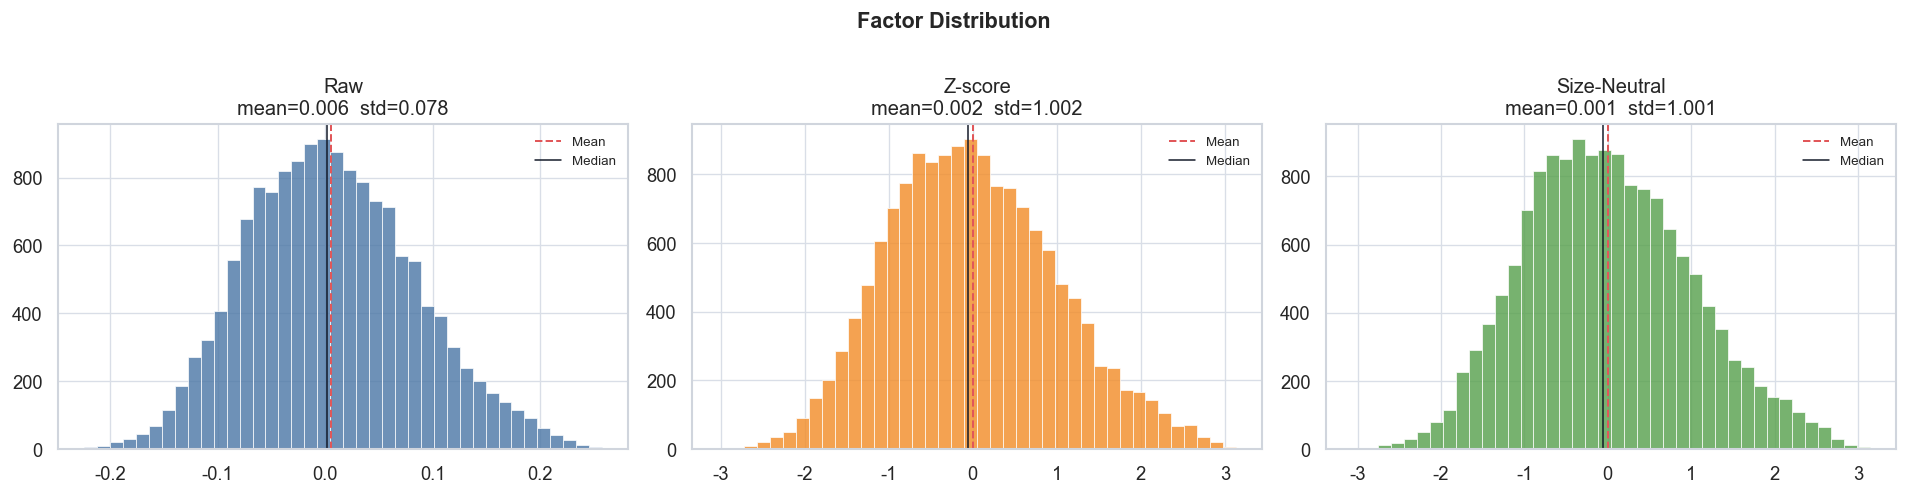

,count,mean,std,skew,p01,p99
version,,,,,,
Raw,14983,0.0059,0.0781,0.2435,-0.1564,0.1972
Z-score,14983,0.0024,1.0017,0.2687,-2.0358,2.4908
Size-Neutral,14983,0.0006,1.0010,0.2606,-2.0491,2.4674


In [4]:
sample = df[df.universe]
labels = ["Raw", "Z-score", "Size-Neutral"]
cols = ["factor_raw", "factor_zscore", "factor_neutral"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, label, clr in zip(axes, cols, labels, [COLORS["blue"], COLORS["orange"], COLORS["green"]]):
    vals = sample[col].dropna()
    ax.hist(vals, bins=40, color=clr, alpha=0.82, edgecolor="white", linewidth=0.5)
    ax.axvline(vals.mean(), color=COLORS["red"], linestyle="--", linewidth=1.2, label="Mean")
    ax.axvline(vals.median(), color="#111827", linestyle="-", linewidth=0.9, label="Median")
    ax.set_title(f"{label}\nmean={vals.mean():.3f}  std={vals.std():.3f}")
    ax.legend(frameon=False, fontsize=8)

fig.suptitle("Factor Distribution", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

stats = []
for col, label in zip(cols, labels):
    v = sample[col].dropna()
    stats.append({"version": label, "count": len(v), "mean": v.mean(), "std": v.std(),
                  "skew": v.skew(), "p01": v.quantile(0.01), "p99": v.quantile(0.99)})
display(pd.DataFrame(stats).set_index("version"))



---
## Step 2. IC 分析

这一步对应单因子检测里的第一条硬标准：因子排序和未来收益排序，是否大体同向。

IC 可以理解成“今天因子分数高的股票，未来收益是不是也更靠前”。这里用的是 Rank IC，也就是排序相关性。它更适合单因子研究，因为我们通常更关心“高分股票是不是整体跑赢低分股票”，而不是线性拟合得多漂亮。

## 这组图回答什么

- 📌 它回答：因子的预测力是否为正、是否稳定、是否只对某个持有周期有效。
- 👀 `Rank IC - Daily`：每根柱子是一日 IC；橙线是 20 日滚动均值，用来看趋势。
- 👀 `Cumulative IC`：把每日 IC 累加。曲线越稳定向上，说明因子越持续有效。
- 👀 `IC Distribution`：看每日 IC 大多数落在哪里。分布整体偏右，才说明正 IC 更多。
- 👀 `Mean IC by Horizon`：比较 1 日、5 日、20 日未来收益里，哪个周期更适合这个因子。

## 新手怎么看好坏

- ✅ 平均 IC 为正：说明高因子股票未来收益排序整体更靠前。
- ✅ 正 IC 天数超过一半：说明不是偶尔有效。
- ✅ 累计 IC 持续向上：说明效果不是只集中在少数几天。
- ⚠️ 如果每日 IC 上下剧烈乱跳，即使平均值为正，也要怀疑稳定性。
- ⚠️ 如果只有某一个持有周期有效，后面策略设计就要围绕那个周期，不能随便换调仓频率。

## 当前样例怎么读

当前 mock 数据里，IC 均值和胜率是偏正的，累计 IC 也有上行趋势。所以可以初步说：这个动量因子在样例数据里有一定横截面预测力。但这还不是最终结论，因为还要看收益分层是否顺、Q5-Q1 是否能形成稳定收益。


,mean_ic,std_ic,ic_ir,win_rate,n_days
horizon,,,,,
1d,0.0176,0.1080,0.1632,0.5409,159
5d,0.0320,0.1099,0.2914,0.5975,159
20d,0.0463,0.0938,0.4943,0.6855,159


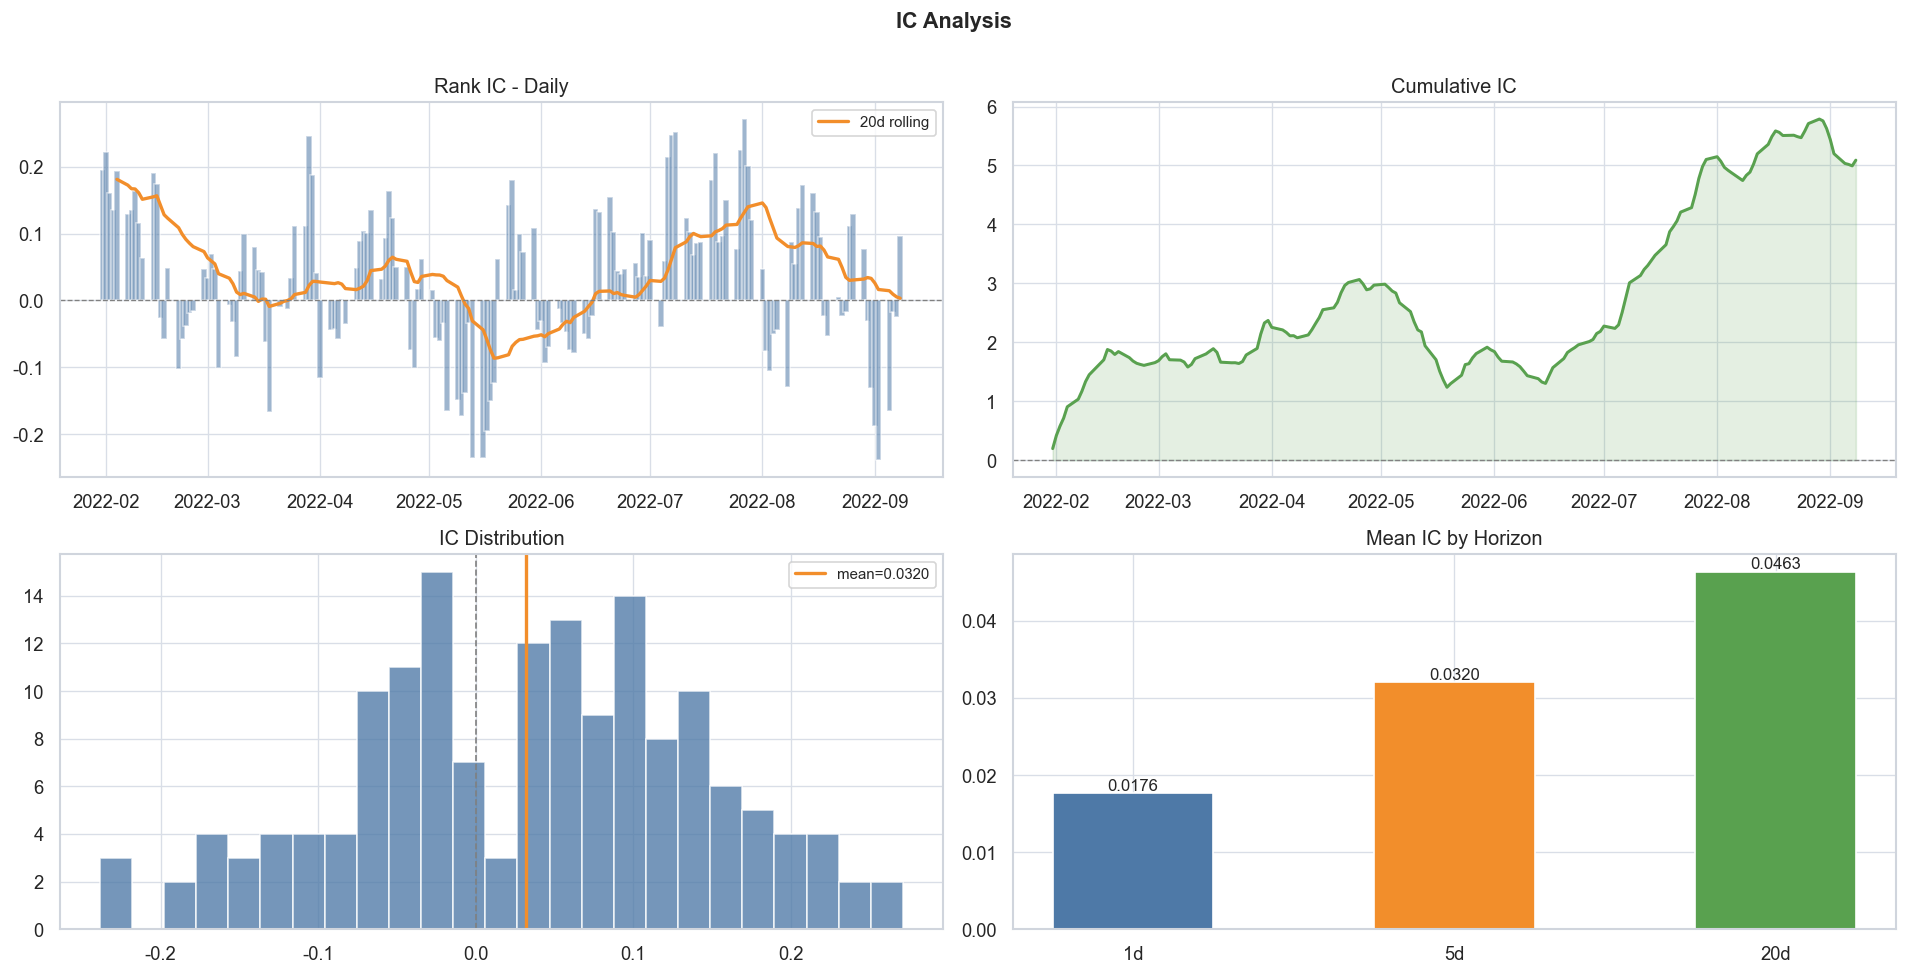

In [5]:
# ── 计算 Rank IC ──
def compute_ic(df, factor_col, fwd_col):
    records = []
    for dt, g in df[df.universe].groupby("trade_date"):
        valid = g[[factor_col, fwd_col]].dropna()
        if len(valid) < 10:
            continue
        ic = valid[factor_col].rank().corr(valid[fwd_col].rank())
        records.append({"trade_date": dt, "rank_ic": ic})
    return pd.DataFrame(records).sort_values("trade_date").reset_index(drop=True)

# 计算多个 horizon 的 IC
ic_frames = {}
for h in FORWARD_HORIZONS:
    ic_frames[h] = compute_ic(df, FACTOR_COL, f"fwd_{h}d")

ic_df = ic_frames[5]  # 主 horizon
ic_df["cum_ic"] = ic_df["rank_ic"].cumsum()
ic_df["rolling_20"] = ic_df["rank_ic"].rolling(20, min_periods=5).mean()

# 统计表
ic_stats = []
for h in FORWARD_HORIZONS:
    ic = ic_frames[h]["rank_ic"].dropna()
    ic_stats.append({
        "horizon": f"{h}d", "mean_ic": ic.mean(), "std_ic": ic.std(),
        "ic_ir": ic.mean() / ic.std() if ic.std() > 0 else np.nan,
        "win_rate": (ic > 0).mean(), "n_days": len(ic)
    })
display(pd.DataFrame(ic_stats).set_index("horizon"))

# ── 图表 ──
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# IC 时间序列
ax = axes[0, 0]
ax.bar(ic_df["trade_date"], ic_df["rank_ic"], color=COLORS["blue"], alpha=0.55, width=1.5)
ax.plot(ic_df["trade_date"], ic_df["rolling_20"], color=COLORS["orange"], linewidth=2, label="20d rolling")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Rank IC - Daily")
ax.legend()

# 累计 IC
ax = axes[0, 1]
ax.plot(ic_df["trade_date"], ic_df["cum_ic"], color=COLORS["green"], linewidth=1.8)
ax.fill_between(ic_df["trade_date"], 0, ic_df["cum_ic"], color=COLORS["green"], alpha=0.16)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Cumulative IC")

# IC 分布直方图
ax = axes[1, 0]
ax.hist(ic_df["rank_ic"], bins=25, color=COLORS["blue"], alpha=0.78, edgecolor="white")
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.axvline(ic_df["rank_ic"].mean(), color=COLORS["orange"], linewidth=2,
           label=f'mean={ic_df["rank_ic"].mean():.4f}')
ax.set_title("IC Distribution")
ax.legend()

# 多 horizon IC 对比
ax = axes[1, 1]
x = np.arange(len(FORWARD_HORIZONS))
means = [ic_frames[h]["rank_ic"].mean() for h in FORWARD_HORIZONS]
bars = ax.bar(x, means, color=HORIZON_COLORS, width=0.5)
ax.bar_label(bars, fmt="%.4f")
ax.set_xticks(x)
ax.set_xticklabels([f"{h}d" for h in FORWARD_HORIZONS])
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Mean IC by Horizon")

fig.suptitle("IC Analysis", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()




---
## Step 3. 分层收益

这一步对应单因子检测里的“经济含义验证”。IC 告诉我们排序相关性，分层收益告诉我们这个排序能不能转成更直观的收益差。

做法是：每天把股票按因子值分成 5 组，然后看每组未来收益。

- Q1：因子最低的一组。
- Q5：因子最高的一组。
- 如果因子方向是正的，我们希望 Q5 的未来收益高于 Q1。

## 这组图回答什么

- 📌 它回答：因子分数越高，未来收益是否越高。
- 👀 左图 `Mean Return by Quantile`：每根柱子是一组股票的平均未来收益。
- 👀 右图 `Cumulative Return by Quantile`：每组收益随时间累积后的曲线。
- ✅ 最理想形态：Q1、Q2、Q3、Q4、Q5 从低到高大体递增，右图里 Q5 长期跑在 Q1 上方。

## 新手怎么看好坏

- ✅ 单调上升最重要：不是只要求 Q5 高，而是希望从低分到高分逐步变好。
- ✅ Q5 和 Q1 差距越清楚，说明因子把好股票和差股票分得越开。
- ⚠️ 如果中间组乱序，说明因子有方向，但排序质量不够细腻。
- ⚠️ 如果只有 Q5 很高、其他组没规律，可能只是头部股票贡献，稳定性要打折。

## 当前样例怎么读

当前样例里，高分组整体更好，说明动量因子的正方向是存在的。但评分卡里会进一步检查 Q1 到 Q5 是否严格单调；如果不严格单调，就代表这个因子的排序能力还不够完美，需要后续用真实数据、行业中性化、交易成本等继续验证。


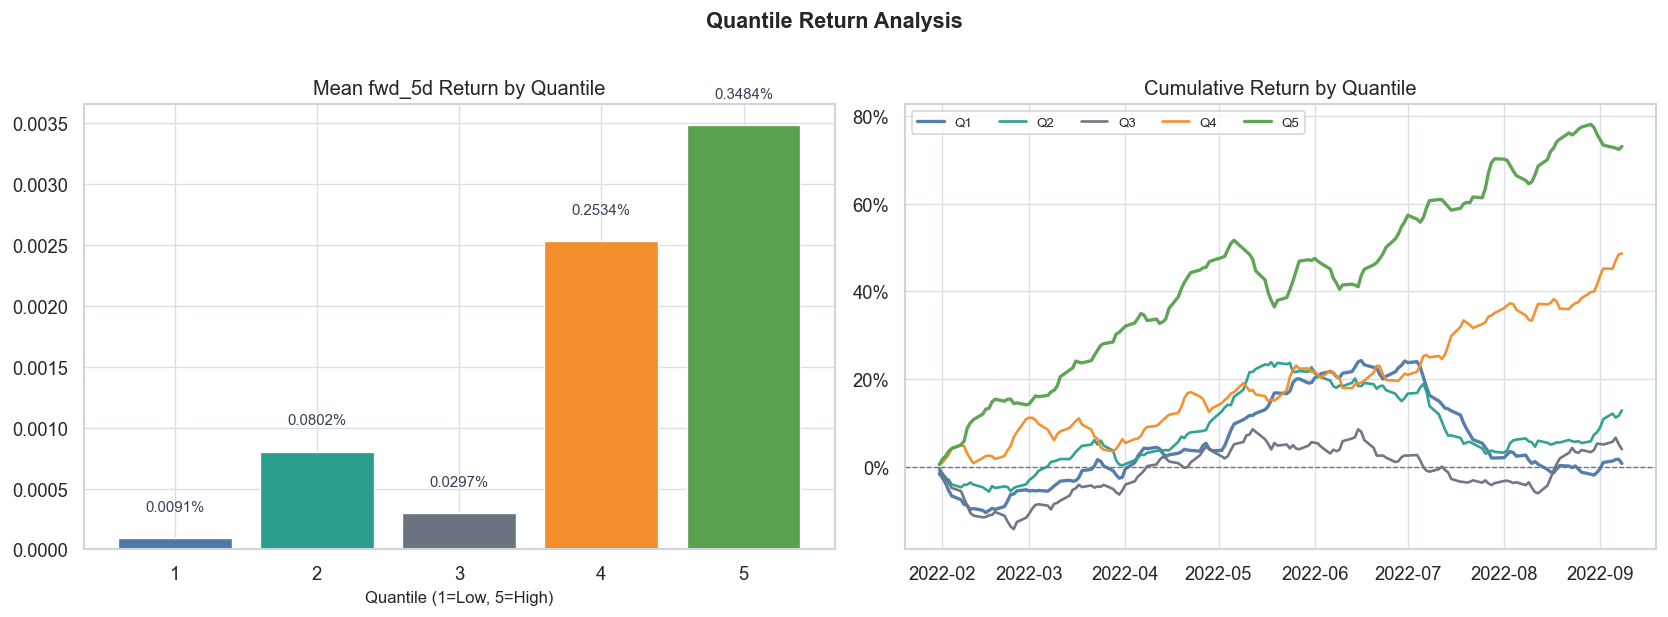

,mean_return,std_return,count,hit_rate
quantile,,,,
1,0.0001,0.0084,159,0.5157
2,0.0008,0.0084,159,0.5786
3,0.0003,0.0093,159,0.5094
4,0.0025,0.0089,159,0.6226
5,0.0035,0.0080,159,0.6855


In [6]:
# 分层收益
valid = df[df.universe & df["quantile"].notna() & df[FWD_COL].notna()]

daily_q = (valid.groupby(["trade_date", "quantile"])[FWD_COL]
           .mean().reset_index().rename(columns={FWD_COL: "avg_return"}))

q_summary = (daily_q.groupby("quantile")["avg_return"]
             .agg(["mean", "std", "count"])
             .rename(columns={"mean": "mean_return", "std": "std_return"}))
q_summary["hit_rate"] = daily_q.groupby("quantile")["avg_return"].apply(
    lambda s: (s > 0).mean())

q_pivot = daily_q.pivot(index="trade_date", columns="quantile", values="avg_return")
q_cum = (1 + q_pivot.fillna(0)).cumprod() - 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(q_summary.index.astype(str), q_summary["mean_return"],
              color=QUANTILE_COLORS, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, q_summary["mean_return"]):
    offset = 0.0002 if val >= 0 else -0.0002
    va = "bottom" if val >= 0 else "top"
    ax.text(bar.get_x() + bar.get_width()/2, val + offset,
            f"{val:.4%}", ha="center", va=va, fontsize=9, color="#374151")
ax.axhline(0, color=COLORS["gray"], linestyle="--", linewidth=0.8)
ax.set_title(f"Mean {FWD_COL} Return by Quantile")
ax.set_xlabel("Quantile (1=Low, 5=High)")

ax = axes[1]
for q in range(1, N_QUANTILES + 1):
    if q in q_cum.columns:
        ax.plot(q_cum.index, q_cum[q], color=QUANTILE_COLORS[q - 1],
                linewidth=2.0 if q in (1, N_QUANTILES) else 1.6,
                alpha=0.96, label=f"Q{q}")
ax.axhline(0, color=COLORS["gray"], linestyle="--", linewidth=0.8)
ax.set_title("Cumulative Return by Quantile")
ax.legend(ncol=5, fontsize=8, frameon=True)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

fig.suptitle("Quantile Return Analysis", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

display(q_summary)


---
## Step 4. 多空收益

这一步对应单因子检测里的“把分层结果压缩成一个最容易比较的指标”。

最常见的做法就是 `Q5 - Q1`：买最高分组，卖最低分组，观察两者之间的收益差。它不是为了马上实盘交易，而是为了快速判断“高分股相对低分股到底有没有优势”。

## 这组图回答什么

- 📌 它回答：高分组相对低分组的收益差是否稳定为正。
- 👀 左图 `Daily Spread`：每天 Q5 收益减 Q1 收益。柱子在 0 上方代表当天高分组赢了低分组。
- 👀 右图 `Cumulative Spread`：把每日 spread 累加。曲线向上代表长期高分组持续跑赢低分组。

## 新手怎么看好坏

- ✅ 日度 spread 平均值为正：说明高分组整体占优。
- ✅ 累计 spread 越平滑向上越好：说明优势不是少数几天贡献的。
- ⚠️ 如果累计曲线大起大落，说明虽然最终赚钱，但过程很不稳定。
- ⚠️ 如果分层收益看起来不错，但 Q5-Q1 很弱，说明因子方向存在，但强度不够。

## 当前样例怎么读

当前样例里，Q5-Q1 的平均 spread 和累计 spread 都是正的，所以从研究结论层面看，这个因子能把高低分股票拉开差距。但交易落地还不能直接下结论，因为这里还没有加入交易成本、冲击成本、涨跌停、停牌和融券限制。


,value
metric,
mean_spread,0.0034
volatility,0.0125
win_rate,0.5786
cum_return,0.6926
max_drawdown,-0.2018
sharpe,0.2711


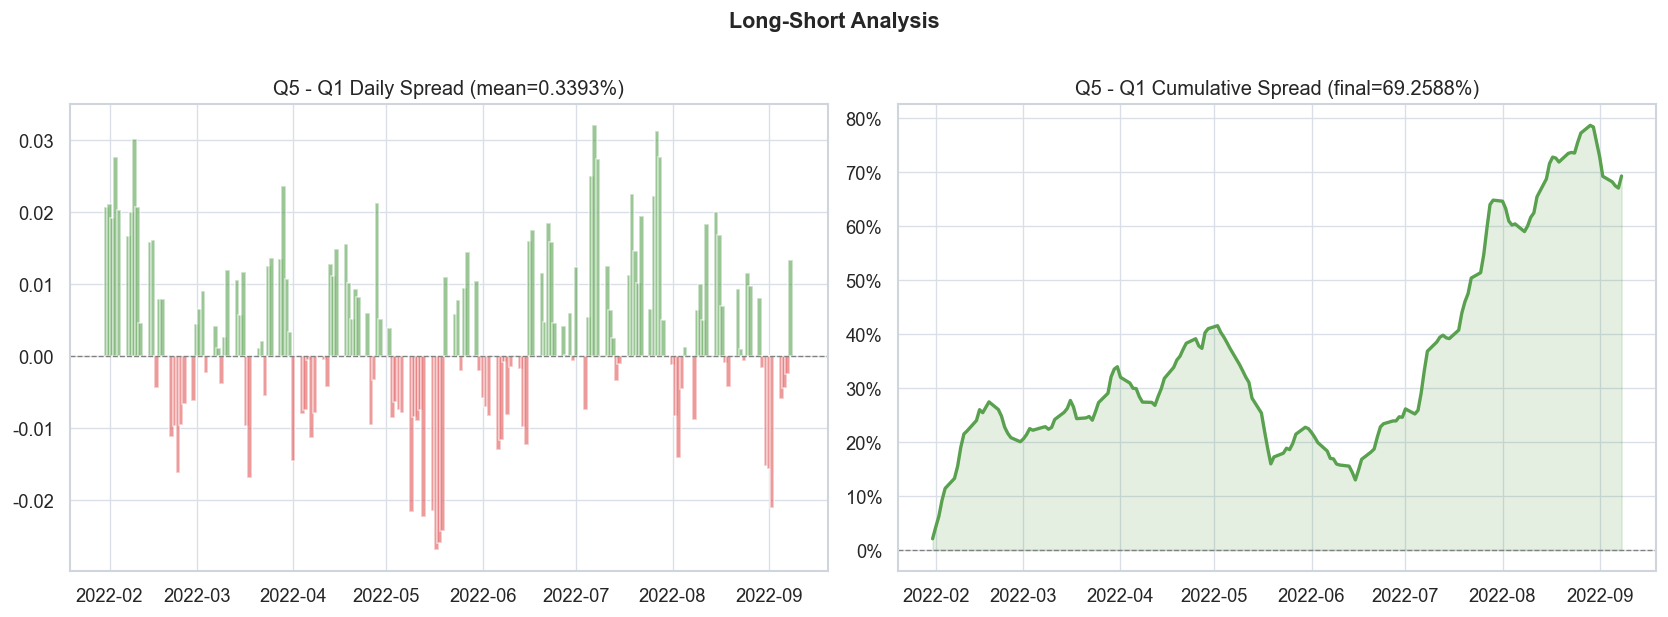

In [7]:
# ── 多空收益 ──
q5 = q_pivot.get(5, pd.Series(0, index=q_pivot.index))
q1 = q_pivot.get(1, pd.Series(0, index=q_pivot.index))
ls = pd.DataFrame({"trade_date": q_pivot.index, "spread": q5 - q1})
ls["cum_spread"] = (1 + ls["spread"].fillna(0)).cumprod() - 1

# 统计
s = ls["spread"].dropna()
cum = (1 + s).cumprod()
dd = (cum / cum.cummax() - 1)
ls_stats = pd.DataFrame({
    "metric": ["mean_spread", "volatility", "win_rate", "cum_return", "max_drawdown", "sharpe"],
    "value": [s.mean(), s.std(), (s > 0).mean(),
              ls["cum_spread"].iloc[-1], dd.min(),
              s.mean() / s.std() if s.std() > 0 else np.nan]
})
display(ls_stats.set_index("metric"))

# ── 图表 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(ls["trade_date"], ls["spread"],
       color=[COLORS["green"] if v >= 0 else COLORS["red"] for v in s], alpha=0.6, width=1.5)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title(f"Q5 - Q1 Daily Spread (mean={s.mean():.4%})")

ax = axes[1]
ax.plot(ls["trade_date"], ls["cum_spread"], color=COLORS["green"], linewidth=2)
ax.fill_between(ls["trade_date"], 0, ls["cum_spread"], color=COLORS["green"], alpha=0.16)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title(f'Q5 - Q1 Cumulative Spread (final={ls["cum_spread"].iloc[-1]:.4%})')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

fig.suptitle("Long-Short Analysis", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()



---
## Step 5. 稳定性检查

这一步对应单因子检测里的“不要只看均值，要看这个因子是不是经得起时间和调仓”。

一个因子可能平均有效，但如果只在前半段有效、排序每天乱跳、换手特别高，实盘价值就会明显下降。

## 这组图回答什么

- 📌 它回答：因子是不是稳定、可持续、可调仓。
- 👀 `20-Day Rolling IC`：看 IC 的短期趋势。橙线持续在 0 上方更好。
- 👀 `Factor Rank Autocorrelation`：看今天和昨天的因子排序像不像。越接近 1，说明排序越稳定。
- 👀 `Quantile Turnover`：看每个分组每天换掉多少股票。越高，代表调仓越频繁。

## 新手怎么看好坏

- ✅ 滚动 IC 长期为正：说明预测力不是只出现在某一小段时间。
- ✅ 秩自相关较高：说明股票排序不乱跳，组合更容易维护。
- ✅ 换手率不过高：说明交易成本更容易控制。
- ⚠️ 秩自相关太低，代表每天选出来的股票变化很大，策略会很难落地。
- ⚠️ 换手率太高，即使纸面收益不错，也可能被交易成本吃掉。

## 当前样例怎么读

当前样例里，排序自相关较高，说明因子排序比较稳定；换手率不是零，说明组合会发生正常调整。结合前后半段 IC 对比，如果前后表现差异不大，就可以说这个因子在样例数据里不是“一阵风式”的偶然有效。


,n,mean_ic,win_rate,ic_ir
period,,,,
Full,159,0.0320,0.5975,0.2914
First Half,79,0.0156,0.5570,0.1407
Second Half,80,0.0482,0.6375,0.4513


,value
metric,
mean_autocorr,0.9492
mean_turnover,0.3316


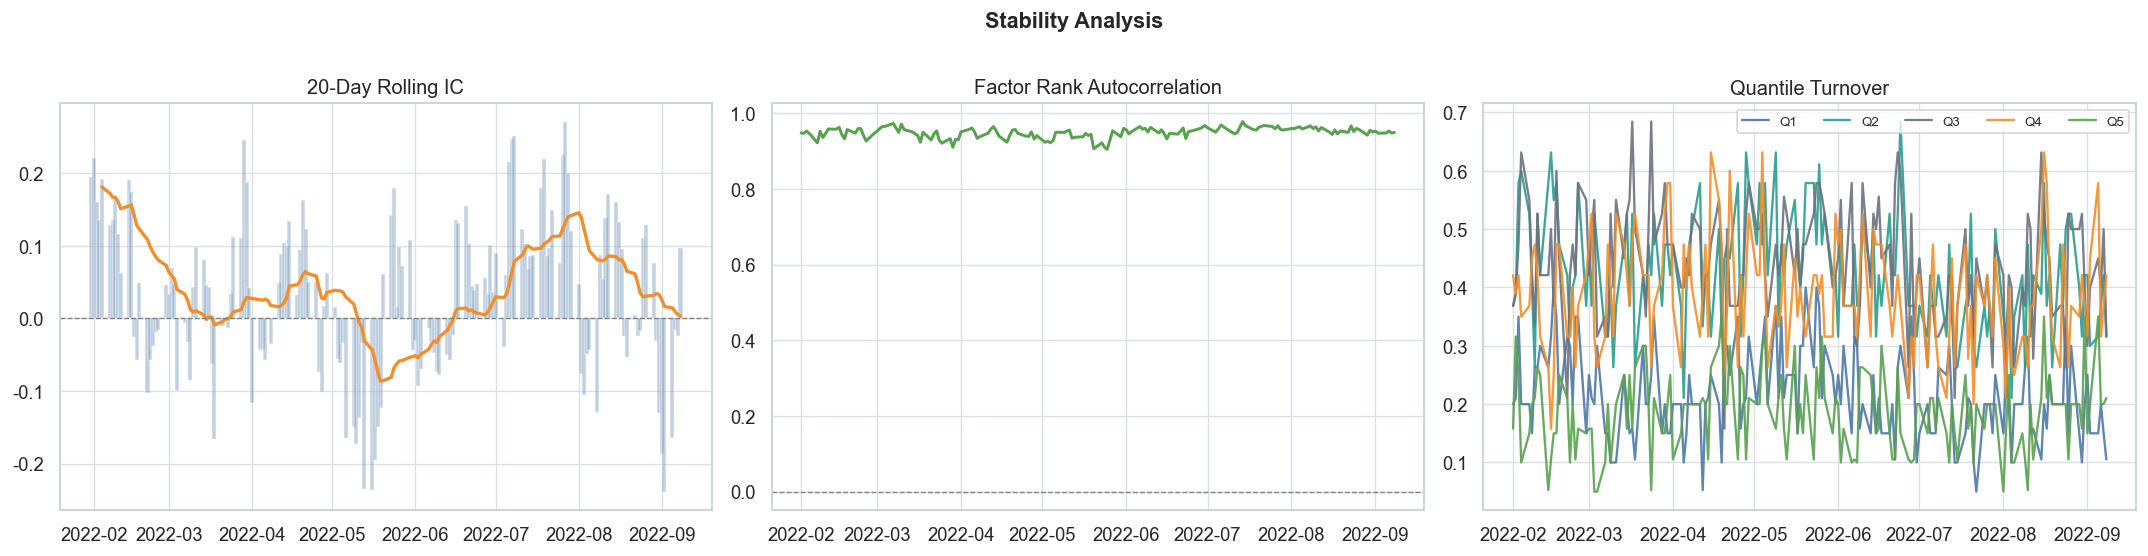

In [8]:
# ── 1) IC 前后半段对比 ──
mid = len(ic_df) // 2
half_stats = []
for label, part in [("全样本", ic_df), ("前半段", ic_df.iloc[:mid]), ("后半段", ic_df.iloc[mid:])]:
    ic = part["rank_ic"].dropna()
    half_stats.append({
        "period": label, "n": len(ic), "mean_ic": ic.mean(),
        "win_rate": (ic > 0).mean(),
        "ic_ir": ic.mean() / ic.std() if ic.std() > 0 else np.nan
    })
half_df = pd.DataFrame(half_stats)
display(half_df.set_index("period"))

# ── 2) 因子秩自相关 ──
dates = sorted(df[df.universe]["trade_date"].unique())
autocorr_rows = []
for d1, d2 in zip(dates[:-1], dates[1:]):
    prev = df[(df.trade_date == d1) & df.universe][["ts_code", FACTOR_COL]].rename(columns={FACTOR_COL: "f_prev"})
    curr = df[(df.trade_date == d2) & df.universe][["ts_code", FACTOR_COL]].rename(columns={FACTOR_COL: "f_curr"})
    m = prev.merge(curr, on="ts_code")
    if len(m) >= 10:
        autocorr_rows.append({"trade_date": d2, "autocorr": m["f_prev"].rank().corr(m["f_curr"].rank())})
autocorr_df = pd.DataFrame(autocorr_rows)

# ── 3) 分组换手率 ──
dates = sorted(df[df.universe & df["quantile"].notna()]["trade_date"].unique())
turnover_rows = []
for d1, d2 in zip(dates[:-1], dates[1:]):
    prev = df[(df.trade_date == d1) & df["quantile"].notna()]
    curr = df[(df.trade_date == d2) & df["quantile"].notna()]
    for q in range(1, N_QUANTILES + 1):
        p_set = set(prev[prev["quantile"] == q]["ts_code"])
        c_set = set(curr[curr["quantile"] == q]["ts_code"])
        if len(c_set) > 0:
            turnover_rows.append({"trade_date": d2, "quantile": q,
                                  "turnover": 1 - len(p_set & c_set) / len(c_set)})
turnover_df = pd.DataFrame(turnover_rows)
t_summary = turnover_df.groupby("quantile")["turnover"].mean().reset_index()
t_summary.columns = ["quantile", "avg_turnover"]

# 摘要
display(pd.DataFrame({
    "metric": ["mean_autocorr", "mean_turnover"],
    "value": [autocorr_df["autocorr"].mean(), turnover_df["turnover"].mean()]
}).set_index("metric"))

# ── 图表 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

ax = axes[0]
ax.bar(ic_df["trade_date"], ic_df["rank_ic"], color=COLORS["blue"], alpha=0.35, width=1.5)
ax.plot(ic_df["trade_date"], ic_df["rolling_20"], color=COLORS["orange"], linewidth=2)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("20-Day Rolling IC")

ax = axes[1]
ax.plot(autocorr_df["trade_date"], autocorr_df["autocorr"], color=COLORS["green"], linewidth=1.8)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Factor Rank Autocorrelation")

ax = axes[2]
for q in range(1, N_QUANTILES + 1):
    part = turnover_df[turnover_df["quantile"] == q]
    ax.plot(part["trade_date"], part["turnover"], color=QUANTILE_COLORS[q - 1], linewidth=1.4, alpha=0.9, label=f"Q{q}")
ax.set_title("Quantile Turnover")
ax.legend(ncol=5, fontsize=8)

fig.suptitle("Stability Analysis", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()



---
## Step 6. 评分卡与研究结论

最后这一步对应单因子检测里的“统一口径汇总”。我们不是看某一个数字，而是把几类证据放在一起判断。

## 评分卡回答什么

- 📌 它回答：前面所有图表合起来，这个因子到底值不值得继续研究。
- 👀 `Mean IC`：平均预测方向。越大越好，但单因子里通常不需要特别大。
- 👀 `IC Win Rate`：IC 为正的日期占比。超过 50% 才说明正向天数更多。
- 👀 `IC IR`：IC 的稳定性。它相当于“平均 IC / IC 波动”。
- 👀 `Q1 -> Q5 Monotonic`：分层收益是否从低分到高分递增。
- 👀 `Q5 - Q1 Mean Spread`：高分组相对低分组的平均优势。
- 👀 `LS Cumulative`：高低分差异长期累积后的结果。
- 👀 `Rank Autocorr`：因子排序稳定性。
- 👀 `Avg Turnover`：组合换手压力。

## 常见判断顺序

1. 先看 `Mean IC` 和 `IC IR`，确认有没有基础预测力。
2. 再看分层单调性，确认排序关系是否清楚。
3. 再看 `Q5 - Q1`，确认收益差能不能被浓缩出来。
4. 最后看稳定性和换手，判断有没有继续做策略化研究的价值。

## 当前样例的研究结论

- ✅ 这个 mock 样例里，动量因子有正向预测力，Q5-Q1 也能形成正 spread。
- ✅ 因子排序比较稳定，不是每天剧烈重排。
- ⚠️ 分层单调性如果显示为 `No`，说明排序关系还不够完美。它不是“因子无效”，而是“因子有效但质量需要继续打磨”。
- ➡️ 下一步接真实 A 股数据时，要继续补行业中性化、交易成本、涨跌停/停牌处理和更长样本期验证。

如果你要向别人解释这个 notebook，可以按一句话讲：先确认因子值健康，再确认 IC 有预测力，再确认分层和多空能转成收益，最后确认稳定性和换手不会让策略落不了地。


In [9]:
# 评分卡
ic_mean = ic_df["rank_ic"].mean()
ic_win = (ic_df["rank_ic"] > 0).mean()
ls_mean = ls["spread"].mean()
ls_cum = ls["cum_spread"].iloc[-1]
auto_mean = autocorr_df["autocorr"].mean()
turnover_mean = turnover_df["turnover"].mean()

monotonic = q_summary["mean_return"].is_monotonic_increasing
q1_mean = q_summary.loc[1, 'mean_return']
q5_mean = q_summary.loc[N_QUANTILES, 'mean_return']

scorecard = pd.DataFrame([
    ["平均 IC", f"{ic_mean:.4f}", "通过" if ic_mean > 0 else "偏弱"],
    ["IC 胜率", f"{ic_win:.1%}", "通过" if ic_win > 0.5 else "偏弱"],
    ["IC IR", f'{ic_mean / ic_df["rank_ic"].std():.3f}', "-"],
    ["Q1 到 Q5 是否单调", "是" if monotonic else "否", "通过" if monotonic else "待看"],
    ["Q5 - Q1 平均价差", f"{ls_mean:.4%}", "通过" if ls_mean > 0 else "偏弱"],
    ["多空累计收益", f"{ls_cum:.4%}", "通过" if ls_cum > 0 else "偏弱"],
    ["排序自相关", f"{auto_mean:.3f}", "-"],
    ["平均换手率", f"{turnover_mean:.1%}", "-"],
], columns=["指标", "数值", "判断"])

def scorecard_row_style(row):
    base = "color: #111827; border-color: #E5E7EB;"
    if row["判断"] == "通过":
        bg = "background-color: #D1FAE5;"
    elif row["判断"] == "偏弱":
        bg = "background-color: #FEE2E2;"
    elif row["判断"] == "待看":
        bg = "background-color: #FEF3C7;"
    else:
        bg = "background-color: #F8FAFC;"
    return [bg + base for _ in row]

scorecard_style = (
    scorecard.style
    .apply(scorecard_row_style, axis=1)
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#111827"), ("color", "#F9FAFB"), ("border-color", "#374151")]},
        {"selector": "td", "props": [("font-weight", "500"), ("border-color", "#E5E7EB")]},
    ])
    .hide(axis="index")
)
display(scorecard_style)

print(f"\n样本：{df.trade_date.nunique()} 个交易日 x {df.ts_code.nunique()} 只股票"
      f" | 有效样本 {df.universe.sum():,} 行"
      f" | 因子：mom_{FACTOR_WINDOW}d | 主收益列：{FWD_COL}")



Metric,Value,Signal
Mean IC,0.0320,OK
IC Win Rate,59.7%,OK
IC IR,0.291,-
Q1 -> Q5 Monotonic,No,Check
Q5 - Q1 Mean Spread,0.3393%,OK
LS Cumulative,69.2588%,OK
Rank Autocorr,0.949,-
Avg Turnover,33.2%,-



Sample: 200 trading days x 100 stocks | valid rows 14,983 | factor: mom_20d | main horizon: fwd_5d
